# Preamble

In [1]:
import numpy as np
import matplotlib.pylab as plt
from scipy.stats import truncnorm

import pymc as pm
import arviz as az
import pytensor.tensor as at
import pytensor.tensor.extra_ops as ate
from pytensor import scan

import astropy.cosmology as cosmo
import astropy.units as u
import h5py
import corner

# Data Generation
$$
m \sim \pi(m|\vec{\lambda}) = f_1 N(m|\mu_1, \sigma_1) + f_2 N(m|\mu_2, \sigma_2) + (1-f_1-f_2) \Bigg(\frac{a(\alpha-1)}{a-\big(\frac{a}{b}\big)^{\alpha}b}\Bigg)\frac{\big(\frac{a}{m}\big)^{\alpha}}{a}
$$

In [2]:
f1 = 0.2
mu1 = 10.0
sigma1 = 1.5
f2 = 0.1
mu2 = 35.0
sigma2 = 3.0
a = 3.0
b = 150.0
alpha = 2.35

In [3]:
class PowerLawPDF(object):
    def __init__(self, alpha, a, b):
        assert alpha > 1

        self.alpha = alpha
        self.a = a
        self.b = b

        self.norm = (self.a - (self.a/self.b)**self.alpha*self.b)/(self.a*(self.alpha-1))

    def __call__(self, x):
        return (self.a/x)**self.alpha/self.a/self.norm
    
    def icdf(self, c):
        return ((self.a**self.alpha*self.b*c + self.a*self.b**self.alpha*(1-c))/(self.a*self.b)**self.alpha)**(1/(1-self.alpha))

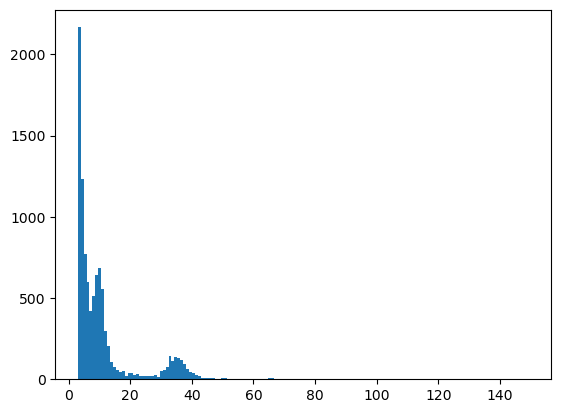

In [4]:
rng = np.random.default_rng(333165393797366967556667466879860422123)

Nobs = 10000

m1 = rng.normal(mu1, sigma1, int(Nobs*f1))
m2 = rng.normal(mu2, sigma2, int(Nobs*f2))
mpowerlaw = PowerLawPDF(alpha,a,b).icdf(rng.uniform(low=0, high=1, size=int(Nobs*(1-f1-f2))))
m = np.concatenate((m1, m2, mpowerlaw))
np.random.shuffle(m)
_ = plt.hist(m, bins=154)

$$
z \sim \pi(z|\kappa) = \text{PowerLaw}(1+z|\kappa, z_{min}=0, z_{max}=2)
$$

In [5]:
kappa = 2.3
zmin = 0.0
zmax = 2.0

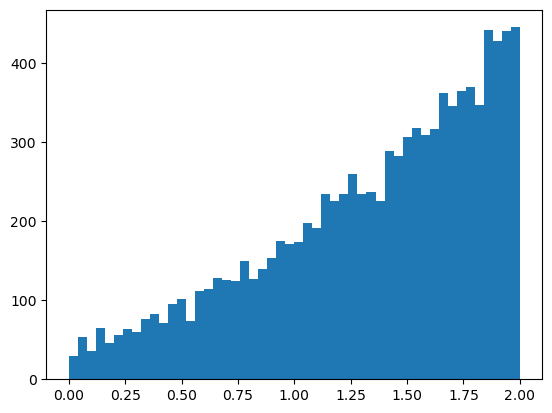

In [6]:
def sample_z_from_1plusz_power(n, k=kappa, zmin=zmin, zmax=zmax, rng=np.random.default_rng()):
    # transform bounds: t = 1/(1+z)
    t_min = 1.0/(1.0 + zmax)  # 1/3
    t_max = 1.0/(1.0 + zmin)  # 1
    alpha = k + 2.0           # 4.3

    pl = PowerLawPDF(alpha=alpha, a=t_min, b=t_max)
    u = rng.random(n)
    t = pl.icdf(u)
    z = 1.0/t - 1.0
    return z

# example usage
z = sample_z_from_1plusz_power(Nobs, k=kappa, zmin=zmin, zmax=zmax, rng=rng)
_ = plt.hist(z, bins=50)

$$
q \sim \pi(q|\beta) = \text{PowerLaw}(q|\beta, q_{min}=0, q_{max}=1)
$$

In [7]:
beta = 3
qmin = 1.0/1000.0
qmax = 1.0

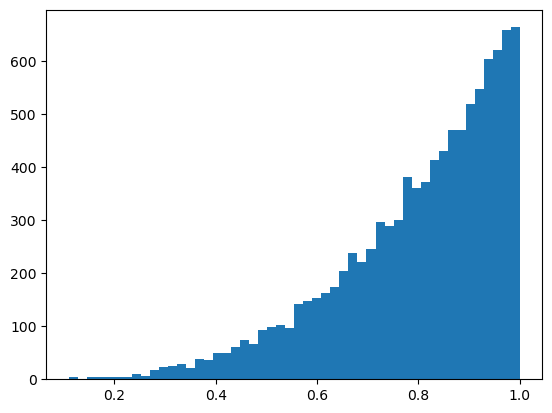

In [8]:
def sample_q_from_q_power(n, beta=beta, qmin=qmin, qmax=qmax, rng=np.random.default_rng()):
    beta1byq = beta + 2.0
    c = 1.0/qmax
    d = 1.0/qmin
    
    pl = PowerLawPDF(alpha=beta1byq, a=c, b=d)
    u = rng.random(n)
    t = pl.icdf(u)
    q = 1.0/t
    return q

q = sample_q_from_q_power(Nobs, rng=rng)
_ = plt.hist(q, bins=50)

$$
\chi_{eff} \sim N(\chi_{eff}|\mu, \sigma)
$$

In [9]:
mu_chieff = 0.15
sigma_chieff = 0.05

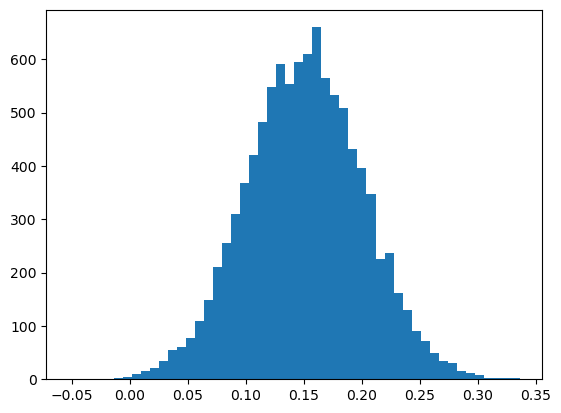

In [10]:
def sample_chieff(n, mu=mu_chieff, sigma=sigma_chieff, lower=-1, upper=1, rng=np.random.default_rng()):
    a, b = (lower - mu) / sigma, (upper - mu) / sigma
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=n, random_state=rng)

chieff = sample_chieff(Nobs, rng=rng)
_ = plt.hist(chieff, bins=50)

# Inference With Truth

In [11]:
def at_powerlaw_pdf(m, alpha, a=a, b=b):
    norm = (a - (a/b)**alpha*b)/(a*(alpha-1))
    return (a/m)**alpha/a/norm

def logpdf_q_power(q, beta, qmin=0.0, qmax=1.0):
    logp = at.log1p(beta) + beta * at.log(q)
    return at.switch(
        (beta > -1) & (q >= qmin) & (q <= qmax),
        logp,
        -at.inf
    )

def logpdf_z(z, k, zmin=0.0, zmax=2.0):
    norm_const = ((1+zmax)**(k+1) - (1+zmin)**(k+1))
    logp = at.log(k+1) + k * at.log1p(z) - at.log(norm_const)
    return at.switch(
        (z >= zmin) & (z <= zmax),
        logp,
        -at.inf
    )

def logpdf_chieff(x, mu, sigma, lower=-1.0, upper=1.0):
    # Standardized bounds
    alpha = (lower - mu) / sigma
    beta  = (upper - mu) / sigma
    z     = (x - mu) / sigma

    # Standard normal CDF via erf
    Phi = lambda t: 0.5 * (1 + at.erf(t / at.sqrt(2.0)))

    Z = Phi(beta) - Phi(alpha)  # normalization

    logp = -0.5 * z**2 - at.log(sigma) - 0.5 * at.log(2*np.pi) - at.log(Z)

    return at.switch((x >= lower) & (x <= upper), logp, -at.inf)

In [12]:
def make_model(m, q, z, chieff):
    
    with pm.Model() as model:
        
        f1 = pm.Uniform('f1', 0.01, 0.9)
        mu1 = pm.Uniform('mu1', 7.0, 20.0)
        sigma1 = pm.Uniform('sigma1', 0.1, 6.0)
        f2 = pm.Uniform('f2', 0.01, 0.9)
        mu2 = pm.Uniform('mu2', 30.0, 40.0)
        sigma2 = pm.Uniform('sigma2', 0.1, 5.0)
        alpha = pm.Uniform('alpha', 1.0, 10.0)

        beta = pm.Uniform('beta', 0.1, 9)

        k = pm.Uniform('k', 0.1, 9)

        mu_chieff = pm.Uniform('mu_chieff', -1.0, 1.0)
        sigma_chieff = pm.Uniform('sigma_chieff', 0.001, 0.3)

        var = f1*at.exp(pm.logp(pm.Normal.dist(mu1, sigma1), m)) + f2*at.exp(pm.logp(pm.Normal.dist(mu2, sigma2), m)) + (1-f1-f2)*at_powerlaw_pdf(m, alpha)
        pm.Potential('var', at.sum(at.log(var)))

        pm.Potential('var1', at.sum(logpdf_q_power(q, beta)))

        pm.Potential('var2', at.sum(logpdf_z(z, k)))

        pm.Potential('var3', at.sum(logpdf_chieff(chieff, mu_chieff, sigma_chieff)))
        
    return model

In [13]:
tune = 1000
target_accept = 0.99
with make_model(m, q, z, chieff) as model:
    trace = pm.sample(tune=tune, target_accept=target_accept)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:01:52

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 113 seconds.


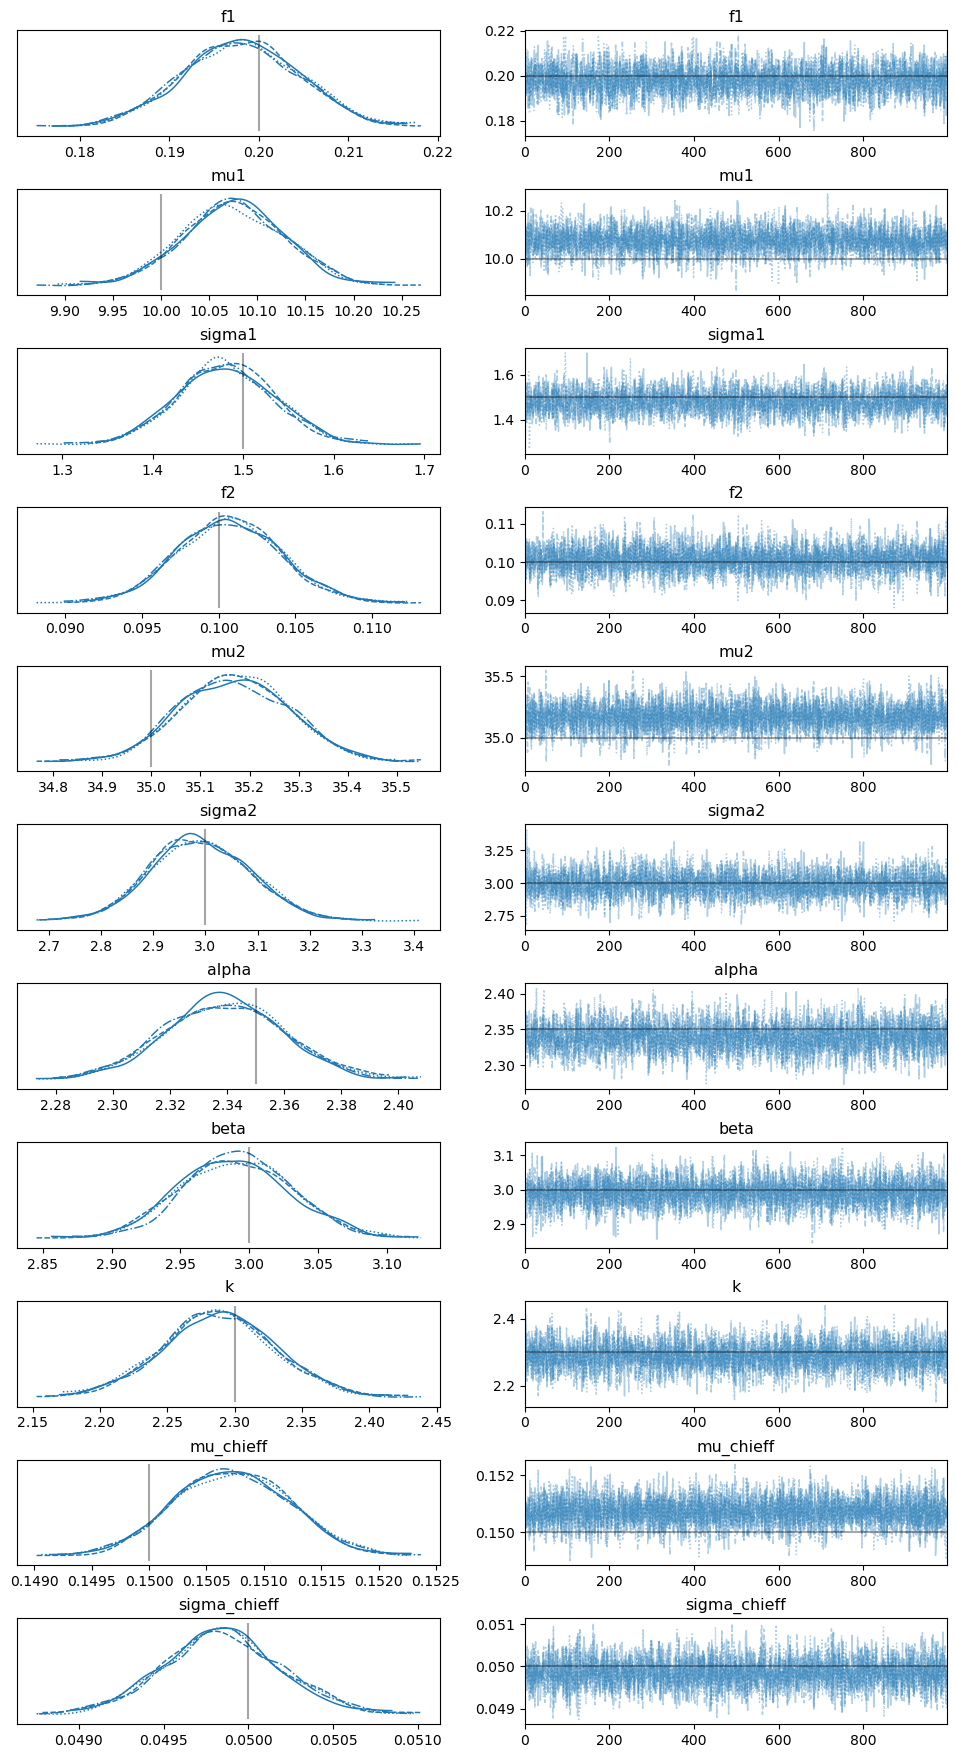

In [14]:
with model:
    axes = az.plot_trace(trace, compact=True, var_names=['f1', 'mu1', 'sigma1', 'f2', 'mu2', 'sigma2', 'alpha', 'beta', 'k', 'mu_chieff', 'sigma_chieff'],
                        lines=[('f1', {}, 0.2),
                        ('mu1', {}, 10.0),
                        ('sigma1', {}, 1.5),
                        ('f2', {}, 0.1),
                        ('mu2', {}, 35.0),
                        ('sigma2', {}, 3.0),
                        ('alpha', {}, 2.35),
                        ('beta', {}, 3.0),
                        ('k', {}, 2.3),
                        ('mu_chieff', {}, 0.15),
                        ('sigma_chieff', {}, 0.05),])
    fig = axes.ravel()[0].figure.subplots_adjust(hspace=0.5)

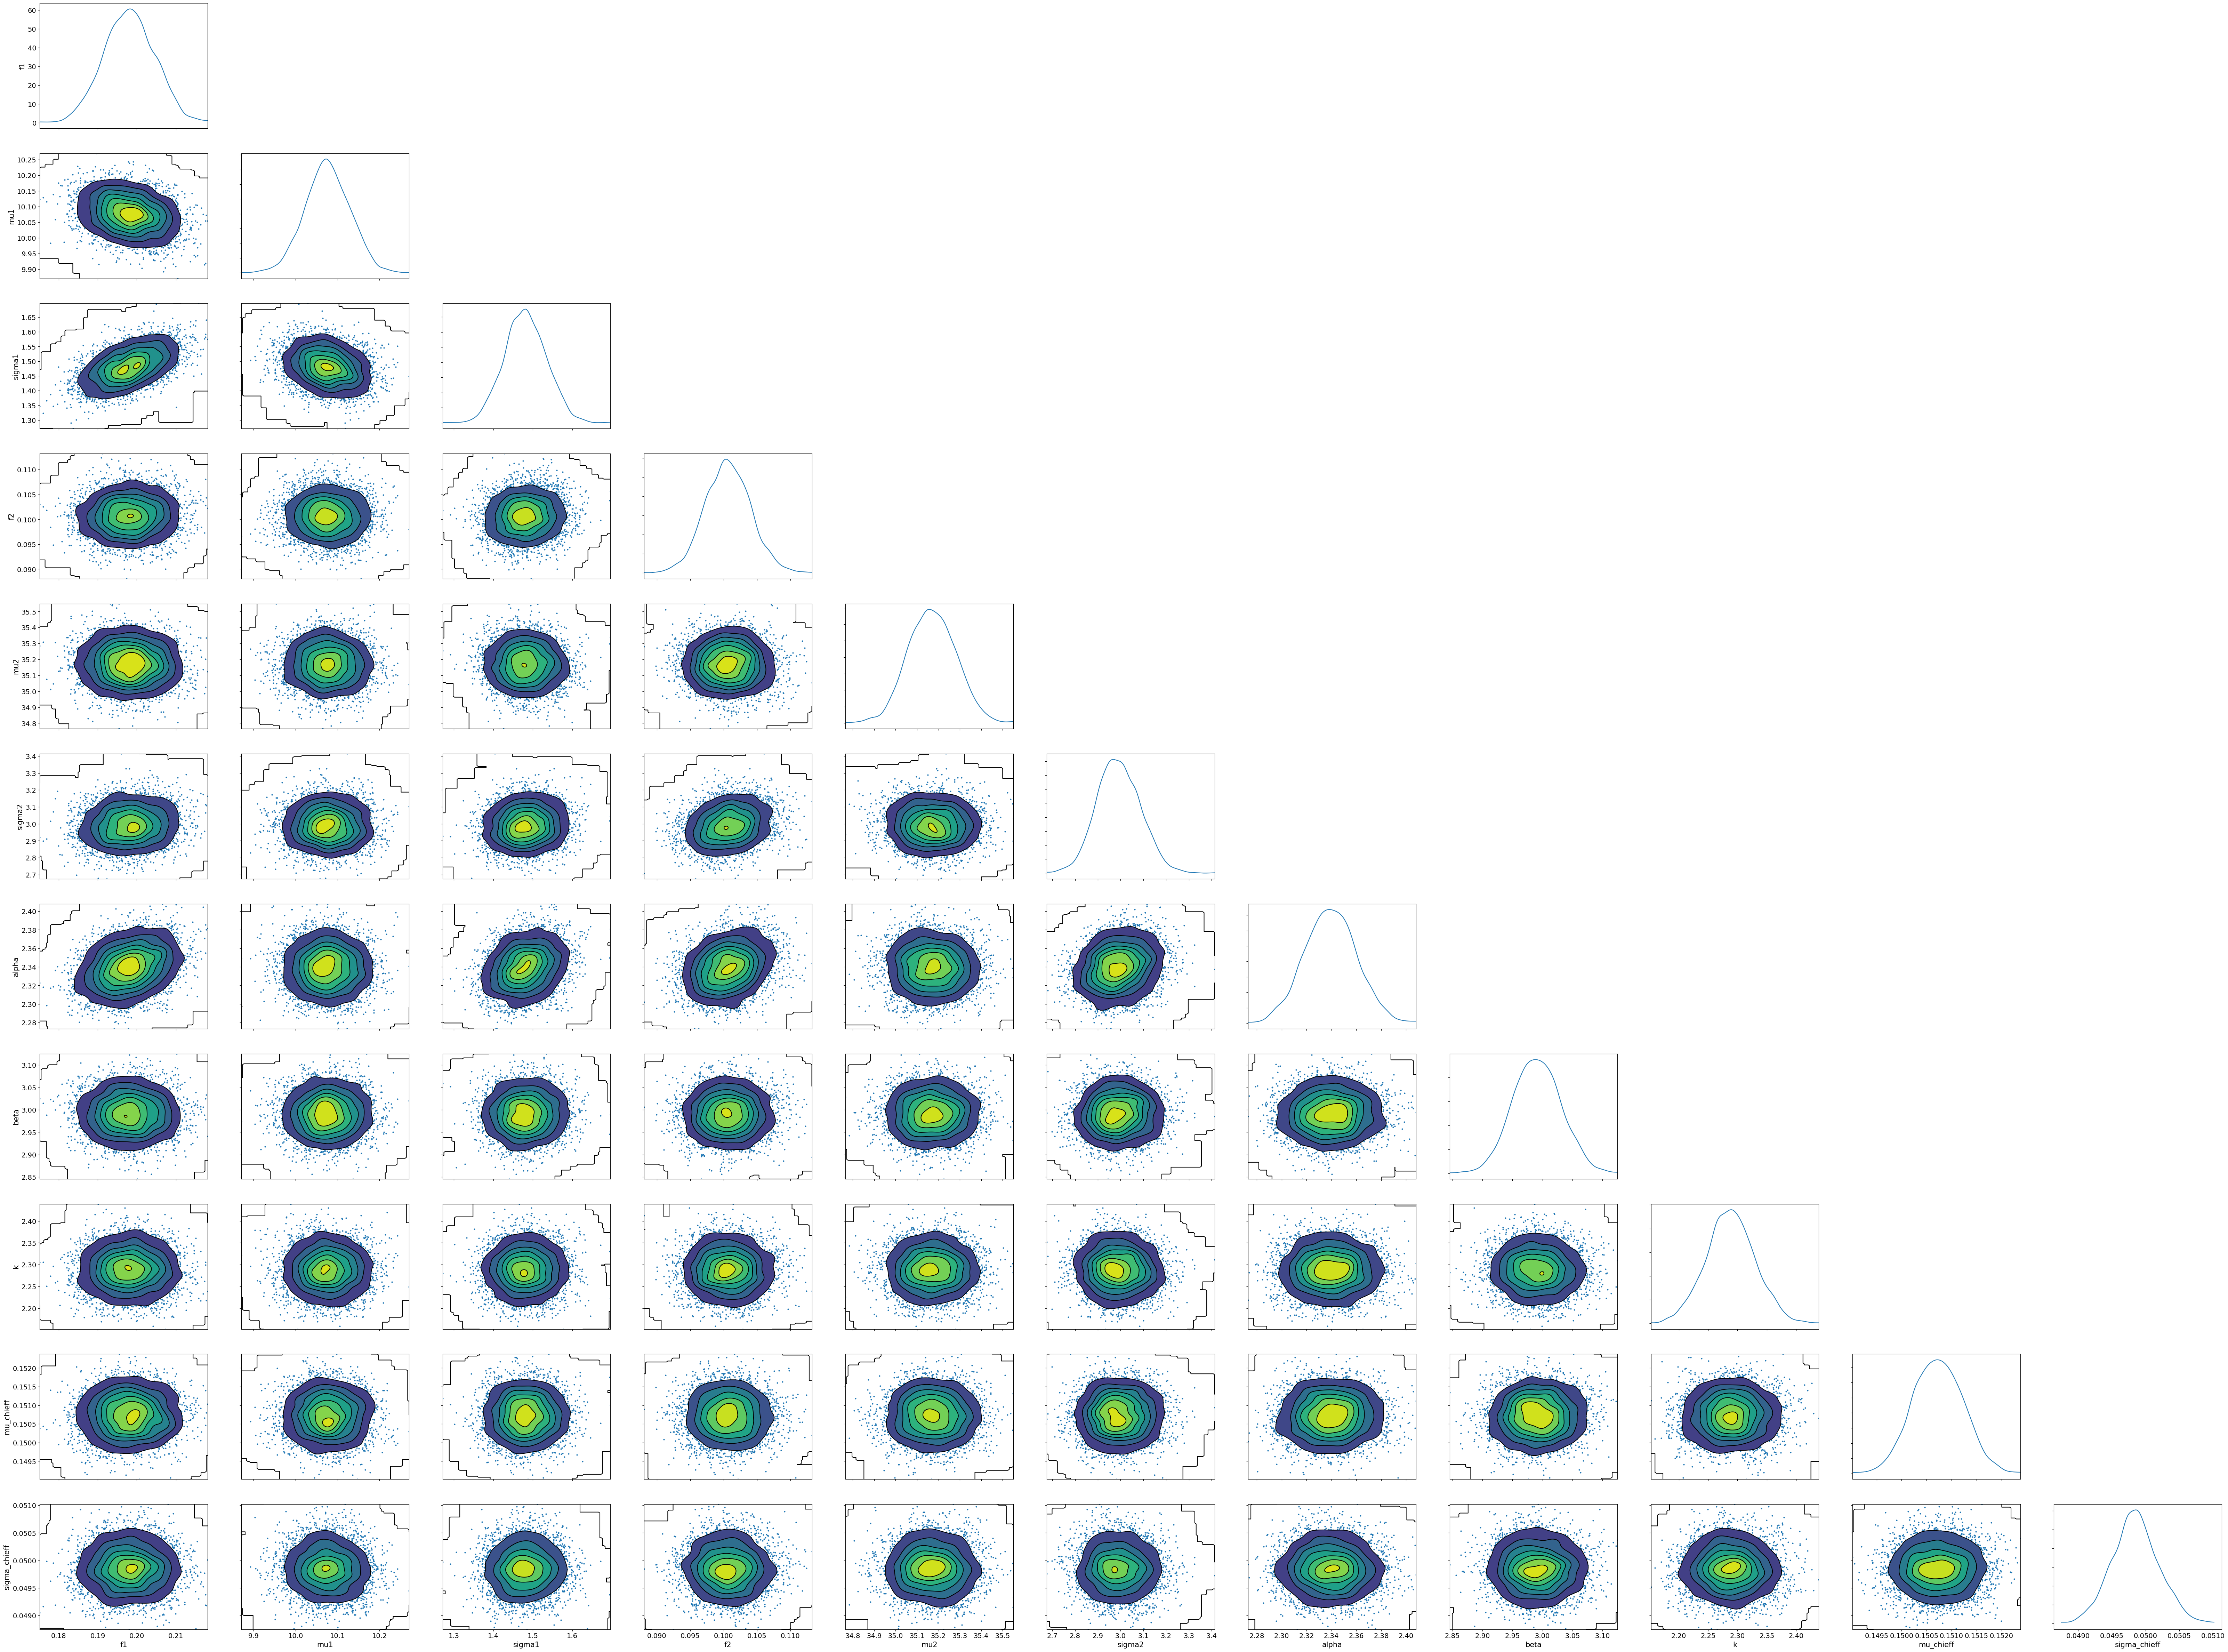

In [15]:
az.rcParams["plot.max_subplots"] = 200
axes1 = az.plot_pair(trace, var_names=['f1', 'mu1', 'sigma1', 'f2', 'mu2', 'sigma2', 'alpha', 'beta', 'k', 'mu_chieff', 'sigma_chieff'], marginals=True, kind=['scatter', 'kde'], divergences=True)
fig = axes1.ravel()[0].figure

# Introduce Cut to the Truth

$$
\pi (m|\vec{\lambda}) = N(m|\mu_2,\sigma_2) + \Big(\frac{1-f_1-f_2}{f_2} \Big) \text{PowerLaw}(m|\alpha,a,b)
$$

In [16]:
f1 = 0.2
f2 = 0.1
alpha = 2.35

In [17]:
def make_model1(m, q, z, chieff):
    
    with pm.Model() as model:

        mu2 = pm.Uniform('mu2', 30.0, 40.0)
        sigma2 = pm.Uniform('sigma2', 0.1, 7.0)
        #fp = pm.Uniform('fp', 0.01, 10.0)
        #alpha = pm.Uniform('alpha', 1.0, 10.0)

        beta = pm.Uniform('beta', 0.1, 9)

        k = pm.Uniform('k', 0.1, 9)

        mu_chieff = pm.Uniform('mu_chieff', -1.0, 1.0)
        sigma_chieff = pm.Uniform('sigma_chieff', 0.001, 0.3)

        var = f2*at.exp(pm.logp(pm.Normal.dist(mu2, sigma2), m)) + (1-f1-f2)*at_powerlaw_pdf(m, alpha)
        pm.Potential('var', at.sum(at.log(var)))
        
        pm.Potential('var1', at.sum(logpdf_q_power(q, beta)))

        pm.Potential('var2', at.sum(logpdf_z(z, k)))

        pm.Potential('var3', at.sum(logpdf_chieff(chieff, mu_chieff, sigma_chieff)))
    return model

In [18]:
tune = 1000
target_accept = 0.99
with make_model1(m[m>20.0], q[m>20.0], z[m>20.0], chieff[m>20]) as model:
    trace = pm.sample(tune=tune, target_accept=target_accept)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:15

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


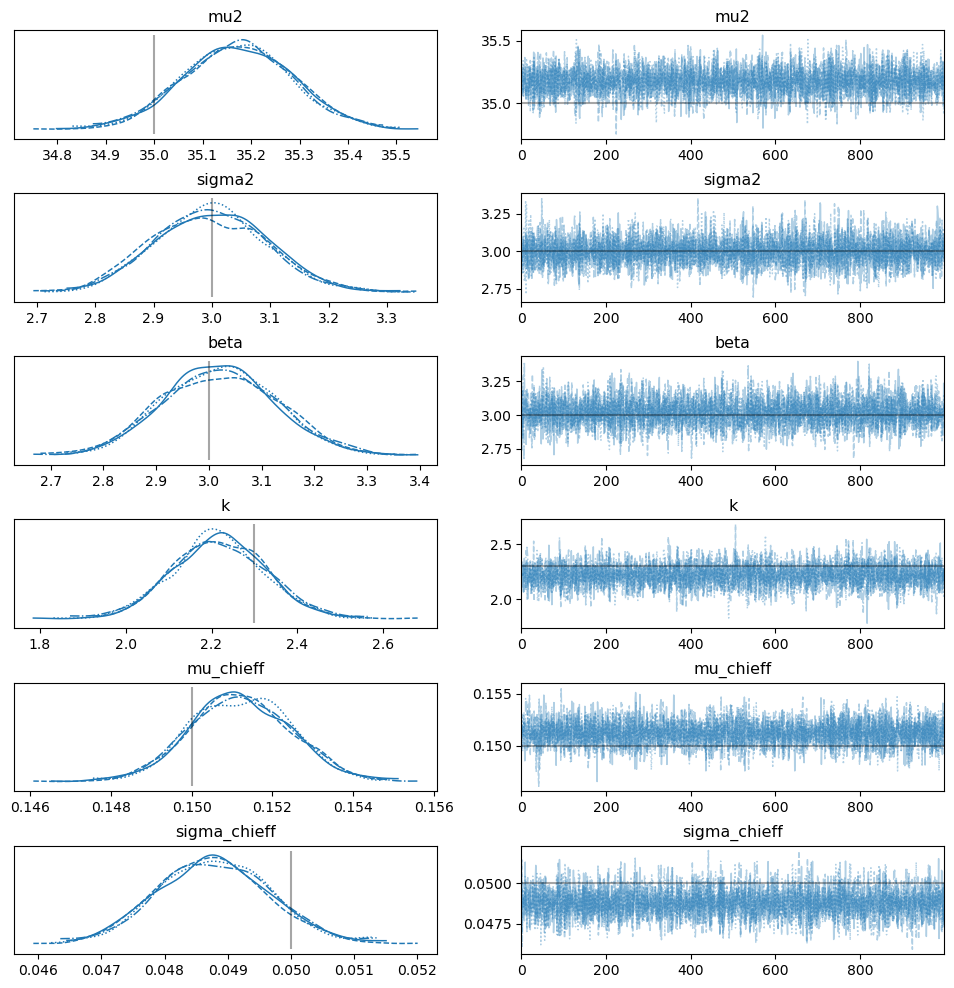

In [19]:
with model:
    axes = az.plot_trace(trace, compact=True, var_names=['mu2', 'sigma2', 'beta', 'k', 'mu_chieff', 'sigma_chieff'],
                        lines=[('mu2', {}, 35.0),
                        ('sigma2', {}, 3.0),
                        ('beta', {}, 3.0),
                        ('k', {}, 2.3),
                        ('mu_chieff', {}, 0.15),
                        ('sigma_chieff', {}, 0.05),])
    fig = axes.ravel()[0].figure.subplots_adjust(hspace=0.5)

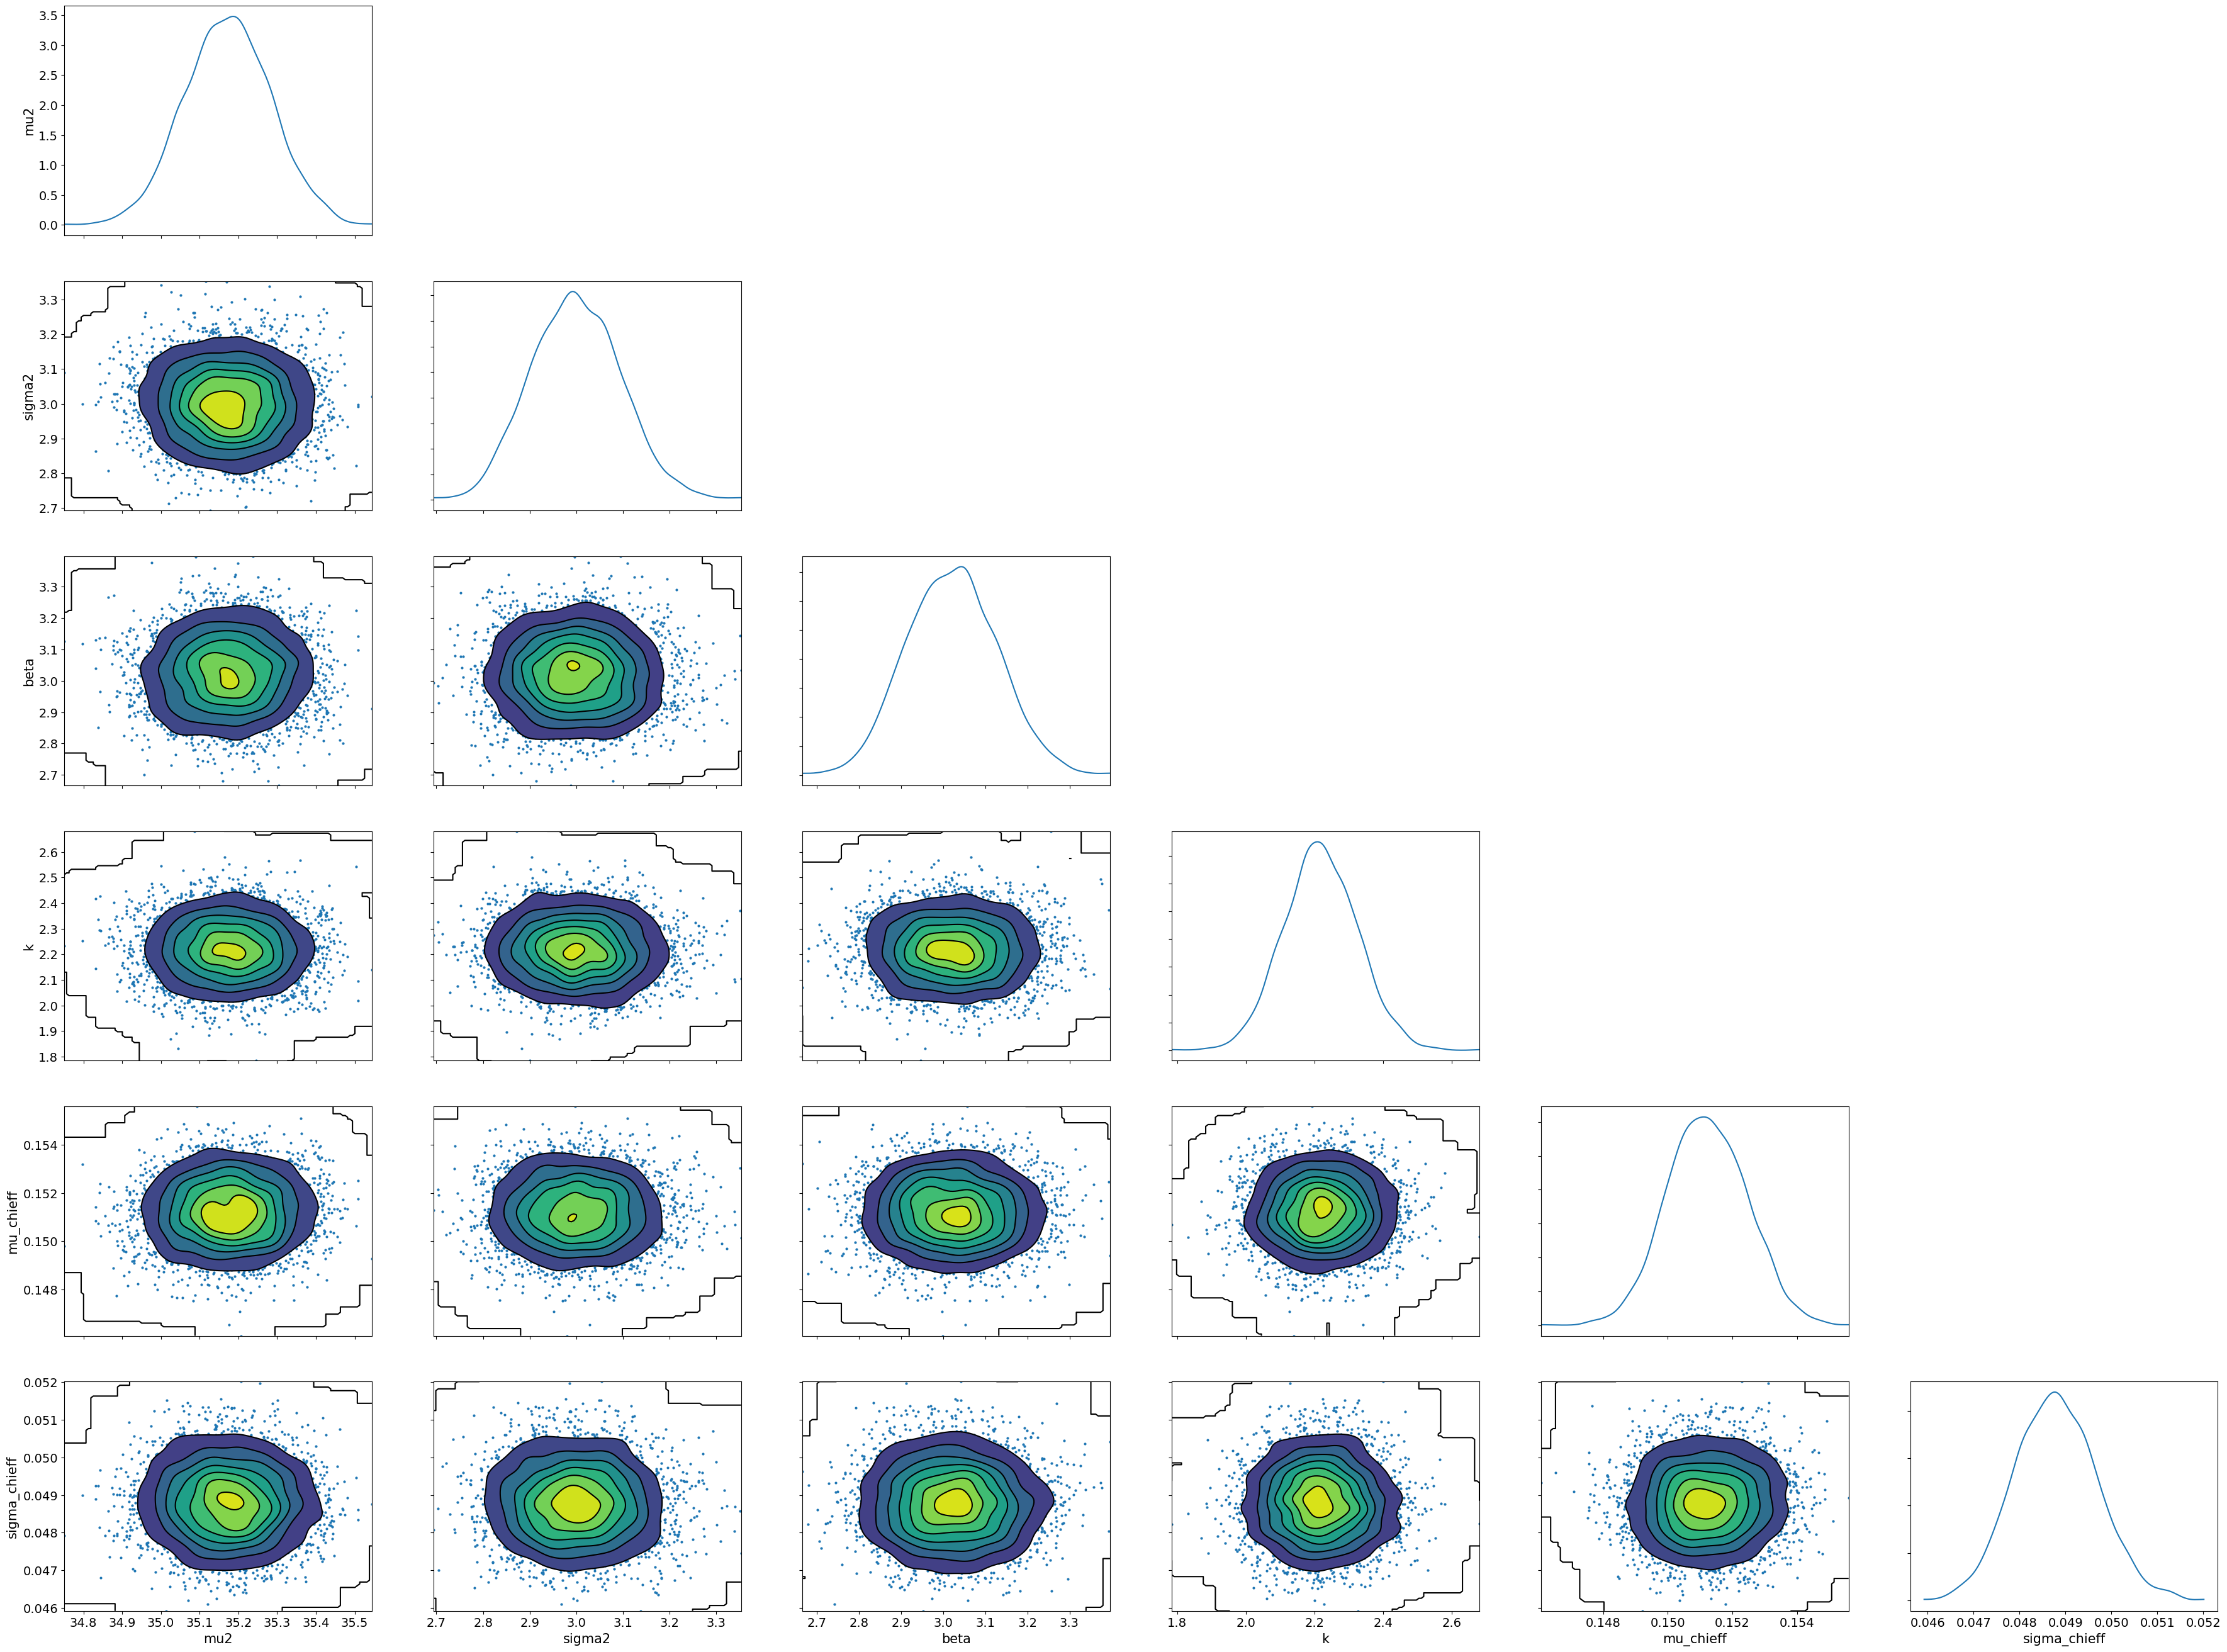

In [20]:
axes1 = az.plot_pair(trace, var_names=['mu2', 'sigma2', 'beta', 'k', 'mu_chieff', 'sigma_chieff'], marginals=True, kind=['scatter', 'kde'], divergences=True)
fig = axes1.ravel()[0].figure

# Errorbar

$$
P(m_{obs}|m) = N(m_{obs}|m, sigma)
$$

In [21]:
sigma_pe = 1.0

mobs = truncnorm.rvs(a=(3.0-m)/1.0, b=(150.0-m)/1.0, loc=m, scale=sigma_pe)
mobs.shape

(10000,)

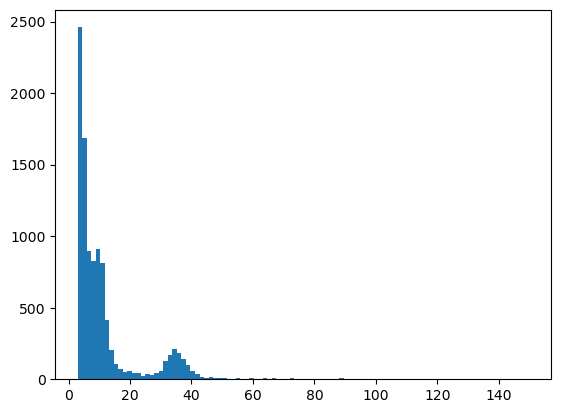

In [22]:
_ = plt.hist(mobs, bins=100)

# Modelling Higher Mass Peak with Errorbar

$$
P(\vec{\lambda}|m_{obs}) \propto \pi(\vec{\lambda}) \prod_{obs} (f_2\mathcal{N}(m_{obs}|\mu_2, \sqrt{\sigma^2+\sigma_2^2}) + (1-f_1-f_2)\int_{m_{min}}^{m_{max}} dm \mathcal{N}(m_{obs}|m, \sigma) \text{PowerLaw}(m|\alpha))
$$

In [23]:
def trapz_pt(y, x):
    dx = x[1:] - x[:-1]
    return at.sum(0.5 * (y[1:] + y[:-1]) * dx)
    
def integrate_one(mobs_i, sigma_i, alpha):
    mdummy = at.linspace(mobs_i - 4*sigma_i, mobs_i + 4*sigma_i, 200)
    integrand = (1/at.sqrt(2*np.pi*sigma_i**2) *
                 at.exp(-0.5*((mdummy - mobs_i)/sigma_i)**2) *
                 at_powerlaw_pdf(mdummy, alpha))
    return trapz_pt(integrand, mdummy)

f1 = 0.2
f2 = 0.1
alpha = 2.35
def make_pop_model_with_errorbar(mobs, sigma_pe=1):
    with pm.Model() as model:
        
        mu2 = pm.Uniform('mu2', 30.0, 40.0)
        sigma2 = pm.Uniform('sigma2', 0.1, 5.0)
        
        sigma22 = at.sqrt(sigma_pe**2 + sigma2**2)

        integrates, _ = scan(fn=lambda mo: integrate_one(mo, sigma_pe, alpha),
                                sequences=[mobs])

        var = (f2 * at.exp(pm.logp(pm.Normal.dist(mu2, sigma22), mobs)) + (1-f1-f2) * integrates)

        pm.Potential("likelihood", at.sum(at.log(var)))

    return model

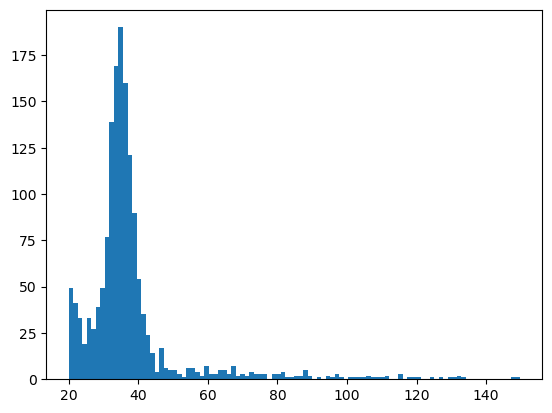

In [24]:
_ = plt.hist(mobs[mobs>20.0], bins=100)

In [25]:
tune = 1000
target_accept = 0.99
with make_pop_model_with_errorbar(mobs[mobs>20.0]) as model:
    trace = pm.sample(tune=tune, target_accept=target_accept)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:04

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


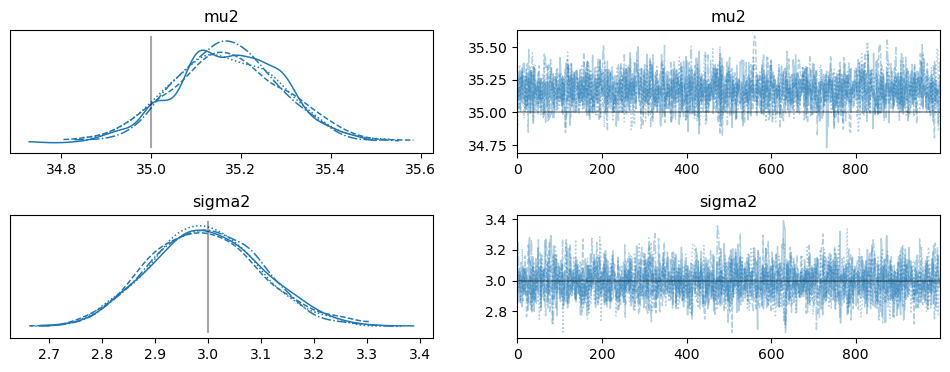

In [26]:
with model:
    axes = az.plot_trace(trace, compact=True, var_names=['mu2', 'sigma2'],
                        lines=[('mu2', {}, 35.0),
                        ('sigma2', {}, 3.0),])
    fig = axes.ravel()[0].figure.subplots_adjust(hspace=0.5)

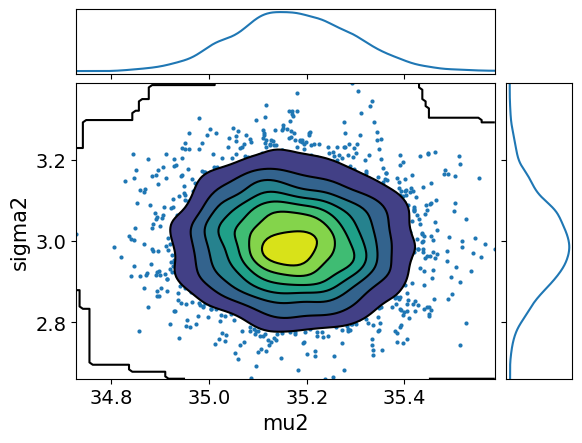

In [27]:
axes1 = az.plot_pair(trace, var_names=['mu2', 'sigma2'], marginals=True, kind=['scatter', 'kde'], divergences=True)
fig = axes1.ravel()[0].figure

In [28]:
qobs = q
zobs = z
chieffobs = chieff

In [29]:
def trapz_pt(y, x):
    dx = x[1:] - x[:-1]
    return at.sum(0.5 * (y[1:] + y[:-1]) * dx)
    
def integrate_one(mobs_i, sigma_i, alpha):
    mdummy = at.linspace(mobs_i - 4*sigma_i, mobs_i + 4*sigma_i, 200)
    integrand = (1/at.sqrt(2*np.pi*sigma_i**2) *
                 at.exp(-0.5*((mdummy - mobs_i)/sigma_i)**2) *
                 at_powerlaw_pdf(mdummy, alpha))
    return trapz_pt(integrand, mdummy)

f1 = 0.2
f2 = 0.1
alpha = 2.35
def make_pop_model_with_errorbar(mobs, qobs, zobs, chieffobs, sigma_pe=1):
    with pm.Model() as model:
        
        mu2 = pm.Uniform('mu2', 30.0, 40.0)
        sigma2 = pm.Uniform('sigma2', 0.1, 5.0)

        beta = pm.Uniform('beta', 0.1, 9)
        k = pm.Uniform('k', 0.1, 9)
        mu_chieff = pm.Uniform('mu_chieff', -1.0, 1.0)
        sigma_chieff = pm.Uniform('sigma_chieff', 0.001, 0.3)
        
        sigma22 = at.sqrt(sigma_pe**2 + sigma2**2)

        integrates, _ = scan(fn=lambda mo: integrate_one(mo, sigma_pe, alpha),
                                sequences=[mobs])

        var = (f2 * at.exp(pm.logp(pm.Normal.dist(mu2, sigma22), mobs)) + (1-f1-f2) * integrates)

        pm.Potential("likelihood", at.sum(at.log(var)))
        pm.Potential('var1', at.sum(logpdf_q_power(qobs, beta)))
        pm.Potential('var2', at.sum(logpdf_z(zobs, k)))
        pm.Potential('var3', at.sum(logpdf_chieff(chieffobs, mu_chieff, sigma_chieff)))

    return model

In [30]:
tune = 1000
target_accept = 0.99
with make_pop_model_with_errorbar(mobs[mobs>20.0], qobs[mobs>20.0], zobs[mobs>20.0], chieffobs[mobs>20.0]) as model:
    trace = pm.sample(tune=tune, target_accept=target_accept)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:15

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


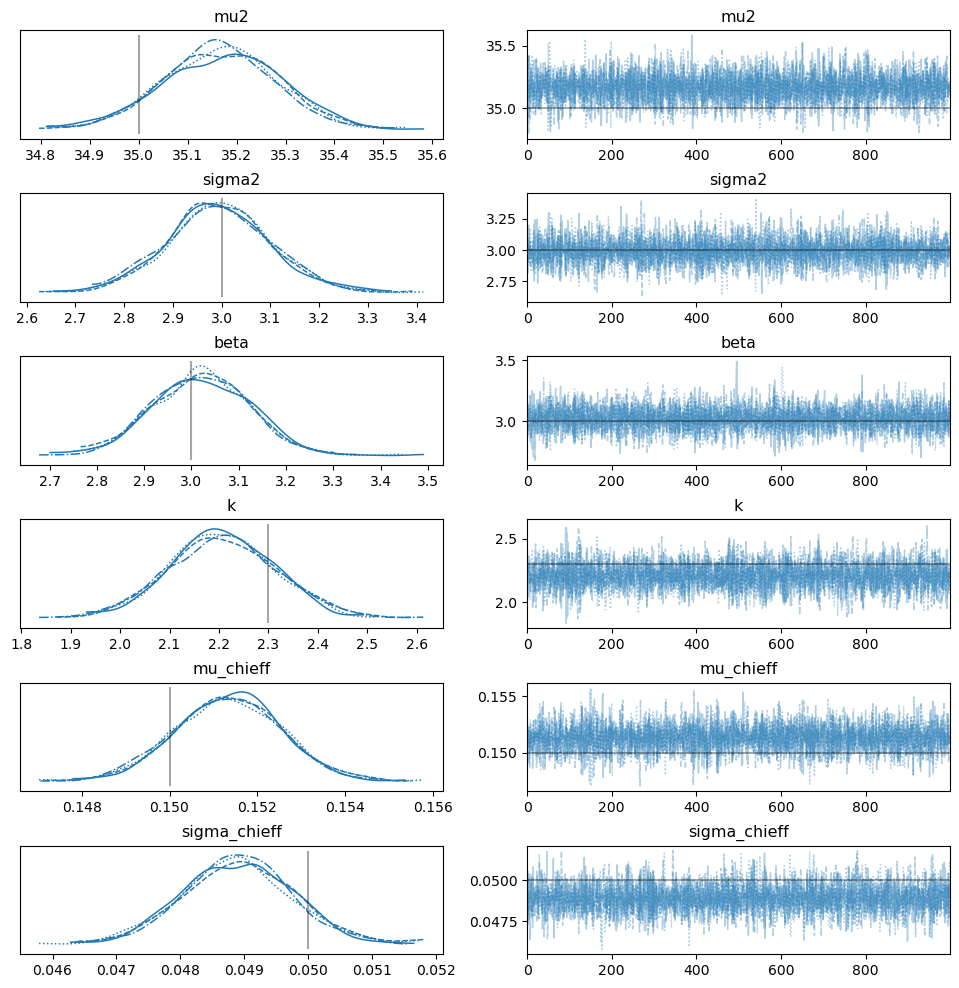

In [31]:
with model:
    axes = az.plot_trace(trace, compact=True, var_names=['mu2', 'sigma2', 'beta', 'k', 'mu_chieff', 'sigma_chieff'],
                        lines=[('mu2', {}, 35.0),
                        ('sigma2', {}, 3.0),
                        ('beta', {}, 3.0),
                        ('k', {}, 2.3),
                        ('mu_chieff', {}, 0.15),
                        ('sigma_chieff', {}, 0.05),])
    fig = axes.ravel()[0].figure.subplots_adjust(hspace=0.5)

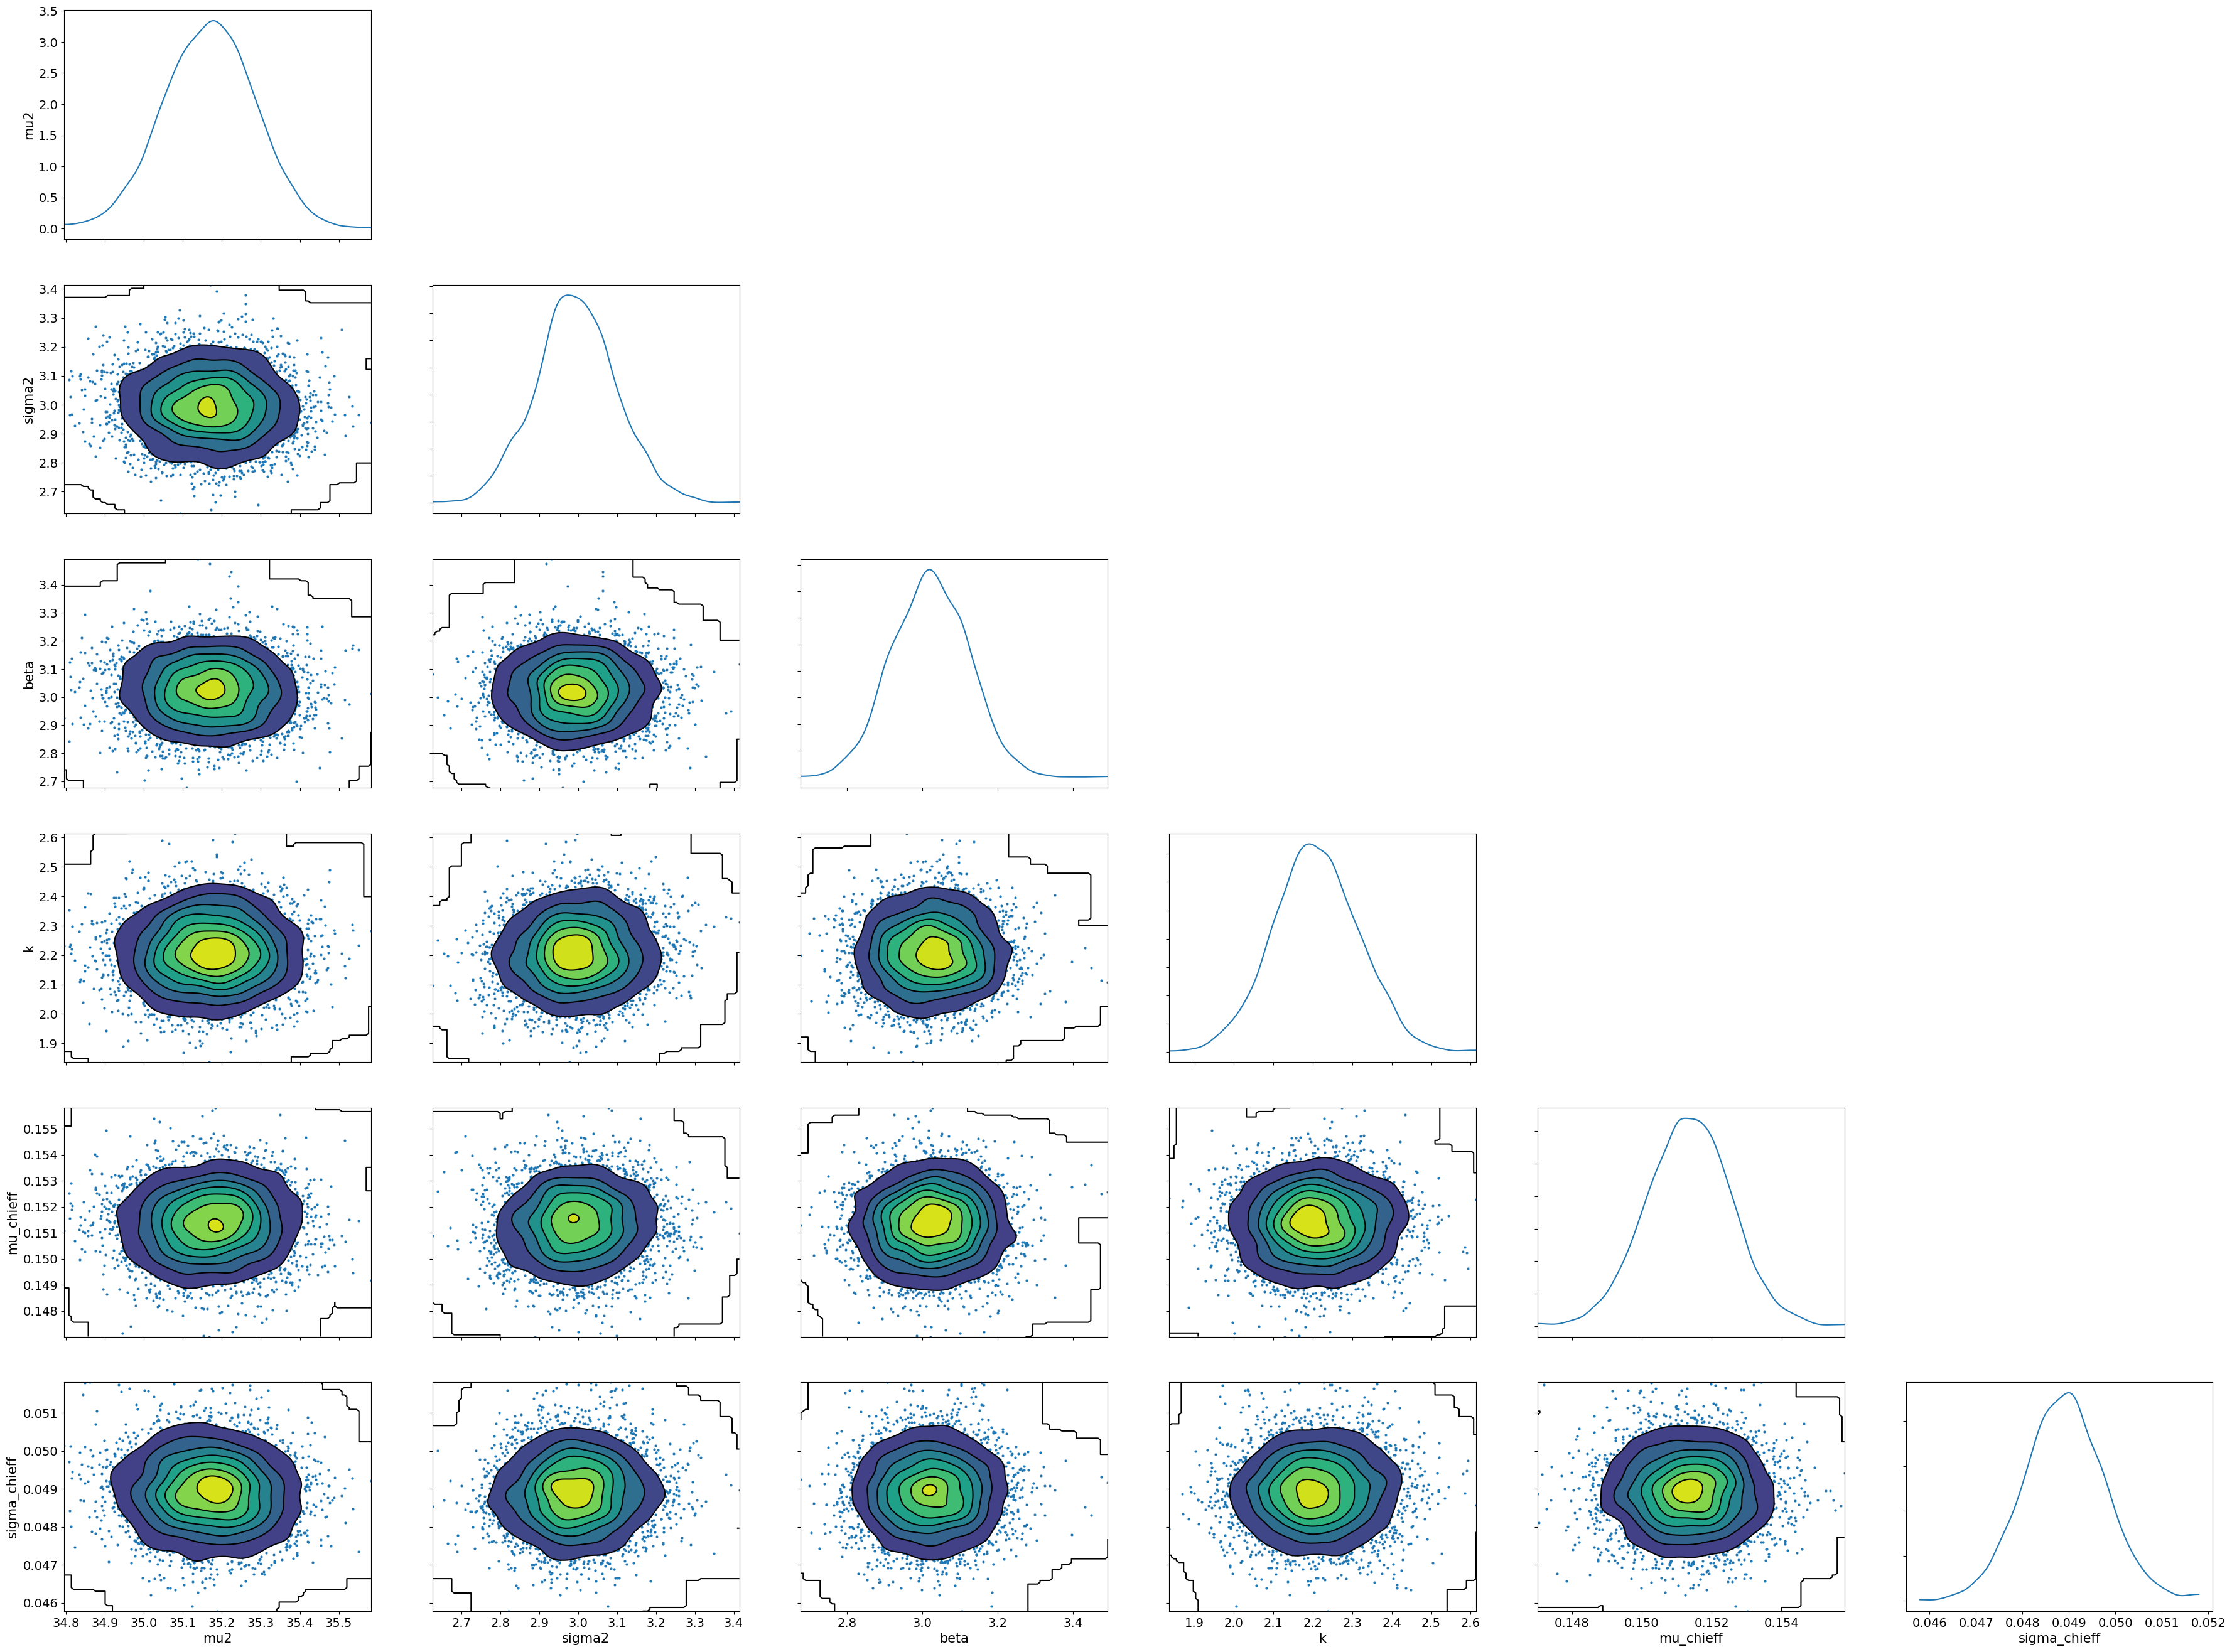

In [32]:
axes1 = az.plot_pair(trace, var_names=['mu2', 'sigma2', 'beta', 'k', 'mu_chieff', 'sigma_chieff'], marginals=True, kind=['scatter', 'kde'], divergences=True)
fig = axes1.ravel()[0].figure

In [33]:
mu2_pos = np.array(trace.posterior.mu2).flatten()
sigma2_pos = np.array(trace.posterior.sigma2).flatten()
beta_pos = np.array(trace.posterior.beta).flatten()
k_pos = np.array(trace.posterior.k).flatten()
mu_chieff_pos = np.array(trace.posterior.mu_chieff).flatten()
sigma_chieff_pos = np.array(trace.posterior.sigma_chieff).flatten()

In [34]:
Nprior = 10000
mu2_prior = np.random.uniform(30.0, 40.0, Nprior)
sigma2_prior = np.random.uniform(0.1, 5.0, Nprior)
beta_prior = np.random.uniform(0.1, 9.0, Nprior)
k_prior = np.random.uniform(0.1, 9.0, Nprior)
mu_chieff_prior = np.random.uniform(-1.0, 1.0, Nprior)
sigma_chieff_prior = np.random.uniform(0.001, 0.3, Nprior)
data_prior = np.array([mu2_prior, sigma2_prior, beta_prior, k_prior, mu_chieff_prior, sigma_chieff_prior]).T

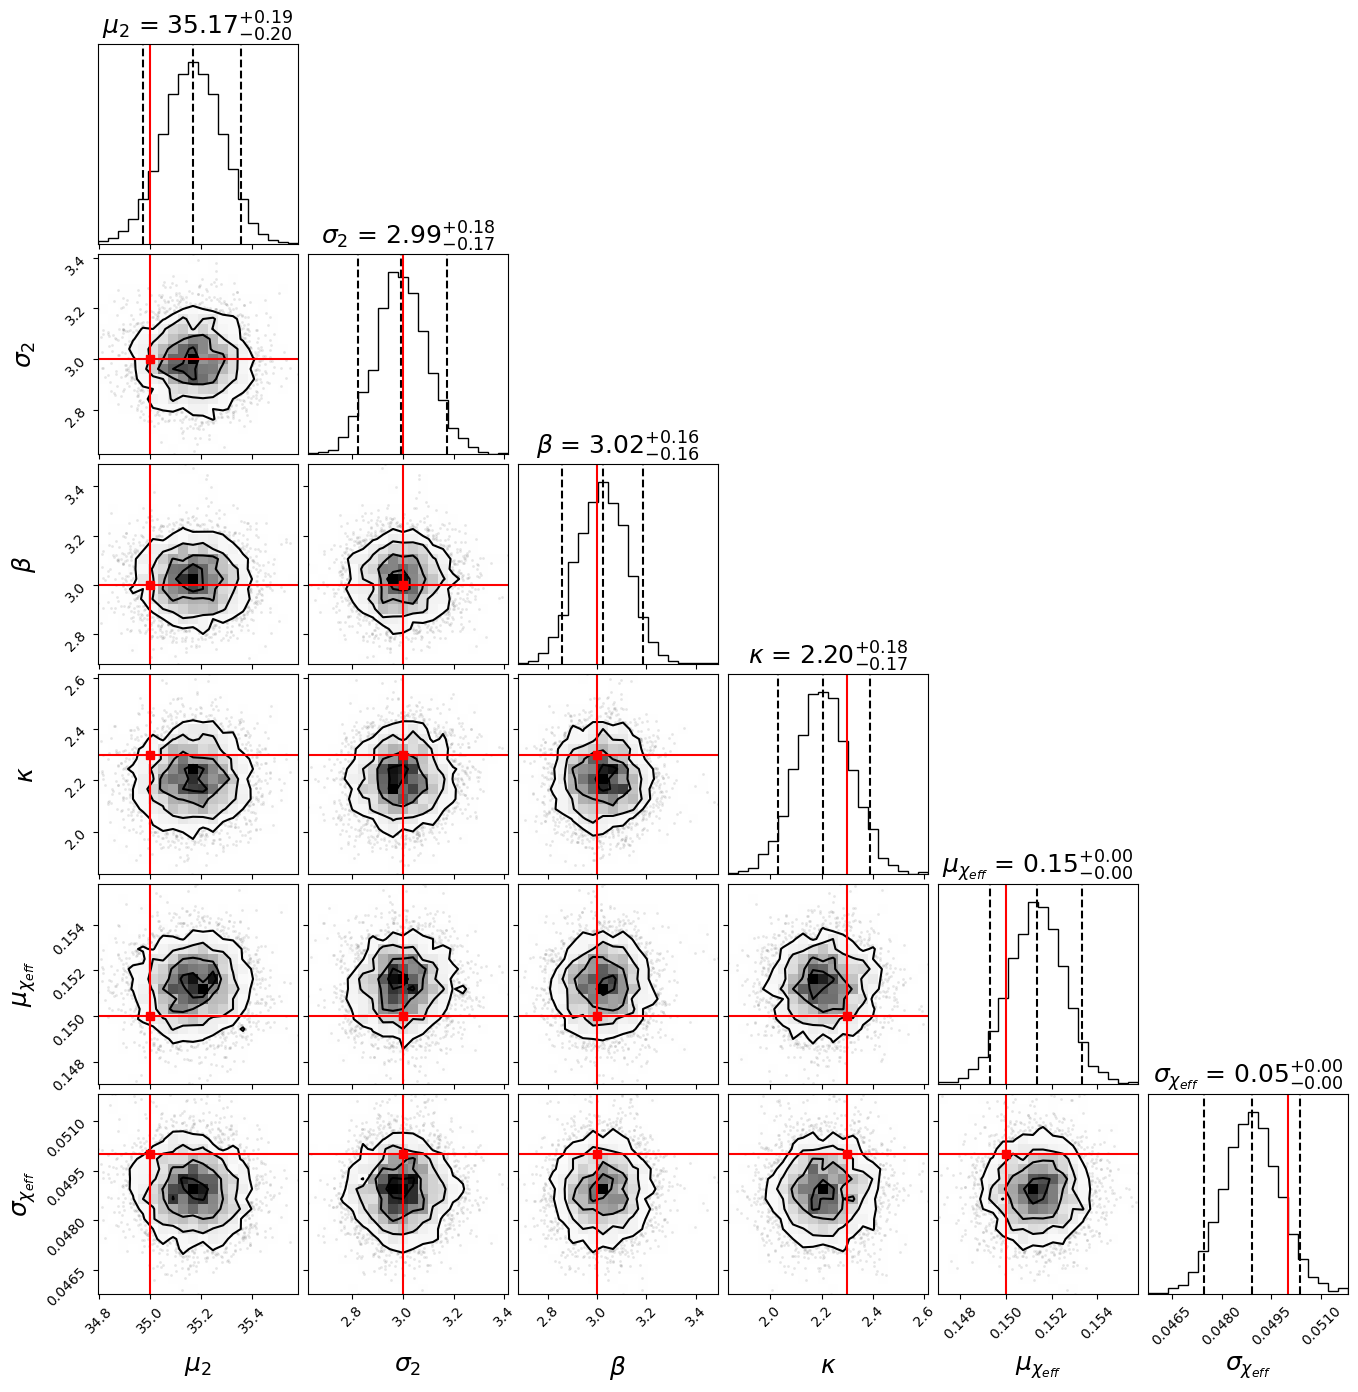

In [38]:
data = np.array([mu2_pos, sigma2_pos, beta_pos, k_pos, mu_chieff_pos, sigma_chieff_pos]).T
true = np.array([35.0, 3.0, 3.0, 2.3, 0.15, 0.05])
figure = corner.corner(
    data,
    labels=[
        r"$\mu_2$",
        r"$\sigma_2$",
        r"$\beta$",
        r"$\kappa$",
        r"$\mu_{\chi_{eff}}$",
        r"$\sigma_{\chi_{eff}}$"
    ],
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_kwargs={"fontsize": 18},
    label_kwargs={"fontsize": 18},
)

# Extract the axes
axes = np.array(figure.axes).reshape((len(true), len(true)))

# Loop over the diagonal
for i in range(len(true)):
    ax = axes[i, i]
    ax.axvline(true[i], color="r")



# Loop over the histograms
for yi in range(len(true)):
    for xi in range(yi):
        ax = axes[yi, xi]
        ax.axvline(true[xi], color="r")
        ax.axhline(true[yi], color="r")
        ax.plot(true[xi], true[yi], "sr")
        
plt.savefig('/mnt/home/sroy1/35Msun_GWTC3/paper_plots/plots/appen_inj_rec.pdf')